<h1 style="color: red; text-align: center;">Assignment (Questions): Penguins</h1>
<h2 style="color: red; text-align: center;">Instructor: Dr. Khaled Mohamad</h2>

## Your Role
You are a junior data analyst at a wildlife research center. Your team collected measurements
of penguins from different islands. Management wants you to **clean the data, explore
patterns,** and finally build a **simple model** to predict the penguin species.
<hr class="solid">

## The work is structured as follows:
Part A: Understanding the Data
Part B: Filtering, Sorting, Aggregation
Part C: Visualization & Interpretation
Part D: Apply ML model

## Import Required Modules, Libraries, and Functions in the Cell Below

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Part A: Understanding the Dataset

## Q1: Load the penguins dataset from seaborn into a DataFrame named df and display the first 5 rows.

In [66]:
df = sns.load_dataset("penguins")

df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Q2: Print the following:

1. dataset shape,
2. column names,
3. data types.

In [67]:
df.shape

(344, 7)

In [68]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [69]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

## Q3: Check for missing values in each column:

In [70]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Q4: Create a cleaned copy called df_clean by:

1. Removing fully duplicated rows (if any)
2. Handling missing values:
   - For numeric columns: fill missing values with the median
   - For categorical columns: fill missing values with the mode
     
Then verify there are no missing values remaining

In [71]:
# 1) Drop duplicates
df_clean = df.drop_duplicates()

In [72]:
# 2) Fill missing values
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [73]:
# Verify
df_clean.isna().sum()
df = df_clean

# Part B: Filtering, Sorting, and Aggregation

## Q5: Filter the dataset to include only penguins from the island "Biscoe" 

Store the result in biscoe_df and print its shape.

In [74]:
biscoe_df = df[df['island'] == "Biscoe"]
biscoe_df.shape

(168, 7)

## Q6: Find all penguins with:

- body_mass_g greater than the overall mean body mass
- AND sex equal to "Male"

Store the result in heavy_males and display the first 5 rows.

In [75]:
heavy_males = df[(df['body_mass_g'] > df['body_mass_g'].median()) & (df['sex'] == "Male")]

heavy_males.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
19,Adelie,Torgersen,46.0,21.5,194.0,4200.0,Male


## Q7: Sort df_clean by:
1. body_mass_g (descending)
2. then bill_length_mm (ascending)
Show the top 10 rows.

In [76]:
df.sort_values(
    by=['body_mass_g', 'bill_length_mm'],
    ascending=[False, True] 
).head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
331,Gentoo,Biscoe,49.8,15.9,229.0,5950.0,Male
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,Male
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,Male
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
295,Gentoo,Biscoe,48.6,16.0,230.0,5800.0,Male


## Q8: Compute the following aggregations:
1. Mean body_mass_g per species . Sort values in descending order.
2. Mean bill_length_mm per ( species , sex )
3. Count of records per island

In [77]:
# 1) Mean body mass per species
df.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64

In [78]:
# 2) Mean bill length per (species, sex)
df.groupby(["species", "sex"])['bill_length_mm'].mean()

species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64

In [79]:
# 3) Count per island
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

## Q9: Feature engineering:
Create a new column bill_ratio = bill_length_mm / bill_depth_mm .
1. Add it to df_clean
2. Show summary statistics for bill_ratio
3. Identify which species has the highest average bill_ratio

In [80]:
#1) Add it to `df_clean`
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']

In [81]:
#2) Show summary statistics for `bill_ratio`
df['bill_ratio'].describe()

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64

In [82]:
#3) Identify which species has the **highest average bill_ratio**
df.groupby("species")['bill_ratio'].mean().sort_values(ascending=True)

species
Adelie       2.122684
Chinstrap    2.653756
Gentoo       3.170703
Name: bill_ratio, dtype: float64

# Part C: Visualization and Interpretation

## Q10: Create the following plots using df_clean :
1. Bar plot: count of penguins per species
2. Scatter plot: bill_length_mm vs bill_depth_mm (color by species)

Text(0.5, 1.0, 'Count of Penguins per Species')

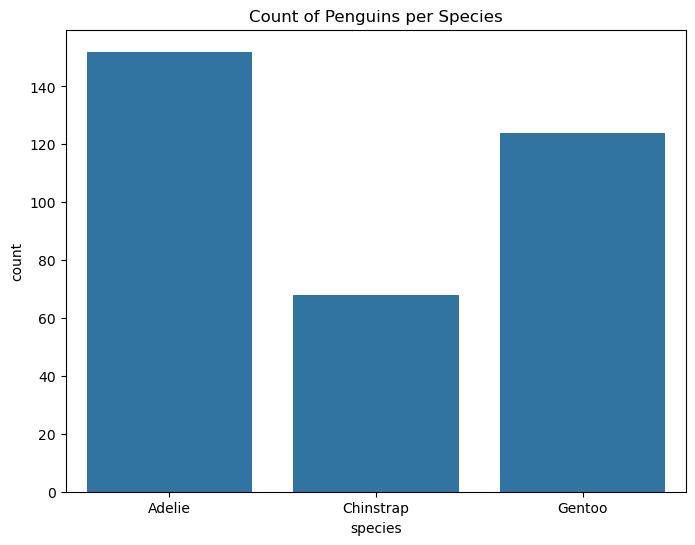

In [83]:
# 1) Count per species (bar)
plt.figure(figsize=(8, 6))
sns.countplot(x=df['species'])
plt.title("Count of Penguins per Species")

Text(0.5, 1.0, 'Bill Length vs Bill Depth')

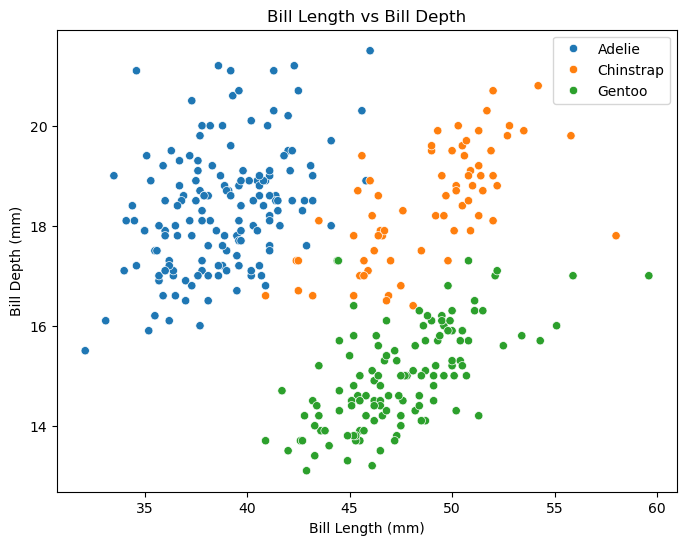

In [84]:
# 2) Scatter: bill length vs bill depth (color by species)
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
    
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend()
plt.title("Bill Length vs Bill Depth")

## Q11: Create a box plot of body_mass_g by species.
Then write 2–3 sentences interpreting what you observe.

Text(0.5, 1.0, 'Body Mass by Species')

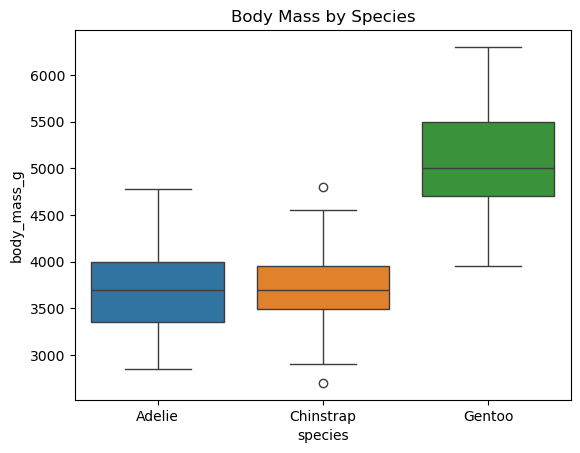

In [85]:
sns.boxplot(data=df, y="body_mass_g", x="species", hue="species")
plt.title("Body Mass by Species")

Interpretation


Gentoo are the heaviest ones. Adelie and Chinstrap are lighter and have similar distributions of weights but chistrap have more outliers.

## Q12: Compute a correlation matrix for numeric features and visualize it as a heatmap

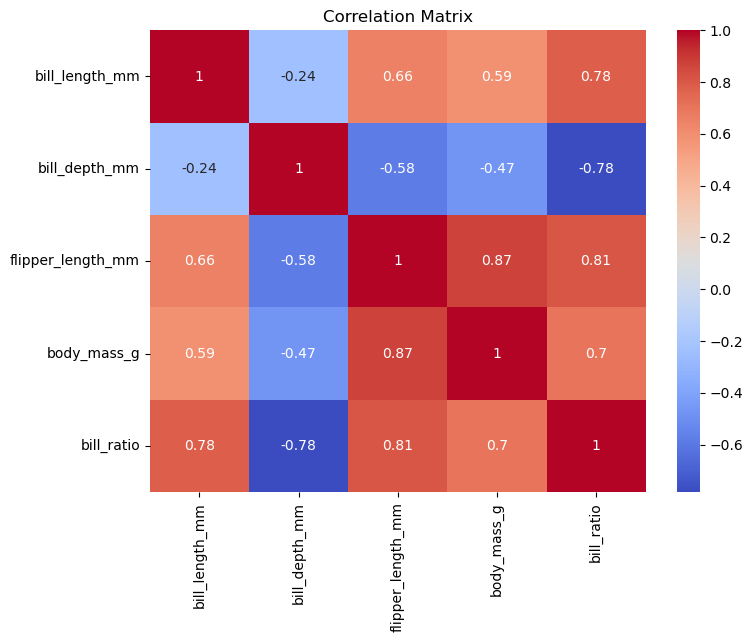

In [86]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(data=corr, cmap='coolwarm', annot=True)
plt.title("Correlation Matrix")
plt.show()

# Part D: Machine Learning
## Q13: 
Define:
- target y = species
- features X = all other columns EXCEPT species

Then split into train/test using:
- test_size = 0.2
- random_state = 42
- stratify by y

In [87]:
X = df.drop(columns='species')
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Q14: Preprocessing Data for ML Training

**This step has already been completed for you. It will be explicitly explained and
discussed in detail during class.** <br/>
- We did the following:<br/>
- Handle missing values (even if we cleaned, do it properly in pipeline)<br/>
- One-hot encode categorical columns ( sex , island )<br/>
- Standardize numeric columns<br/>
Note: You should copy paste this code and run it in the same order as the previous questions

In [88]:
# Identify columns by type
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="median")),
 ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="most_frequent")),
 ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
 transformers=[
 ("num", numeric_transformer, numeric_features),
 ("cat", categorical_transformer, categorical_features),
 ]
)

## Q15: Train models:
1. KNN Classifier with n_neighbors=5

In [89]:
# 1) KNN pipeline
knn_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", KNeighborsClassifier(n_neighbors=5))
])

In [90]:
#Train the model using the fit method
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g',
                                                   'bill_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['island', 'sex'])])),
                ('model', KNeighborsClassifier())])

In [91]:
# Predict on the X_test
y_pred = knn_model.predict(X_test)

In [92]:
#calculate and print the accuracy based on the prediction of the X_test
knn_accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9855072463768116


2. Logistic Regression (multiclass) with max_iter=2000



In [93]:
# 2) Logistic Regression pipeline
logreg_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", LogisticRegression(max_iter=2000))
])

In [94]:
# Train the model using the fit method
logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g',
                                                   'bill_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['island', 'sex'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [95]:
# Predict on the X_test
y_pred = logreg_model.predict(X_test)

In [96]:
#calculate and print the accuracy based on the prediction of the X_test
logreg_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", logreg_accuracy)

Logistic Regression Accuracy: 1.0


## Q16: Conclude based on the accuracy results
### Answer:
Both models perform work on the dataset. Logistic Regression may achieved slightly higher accuracy(1) because of the clear linear separation between species

<Axes: >

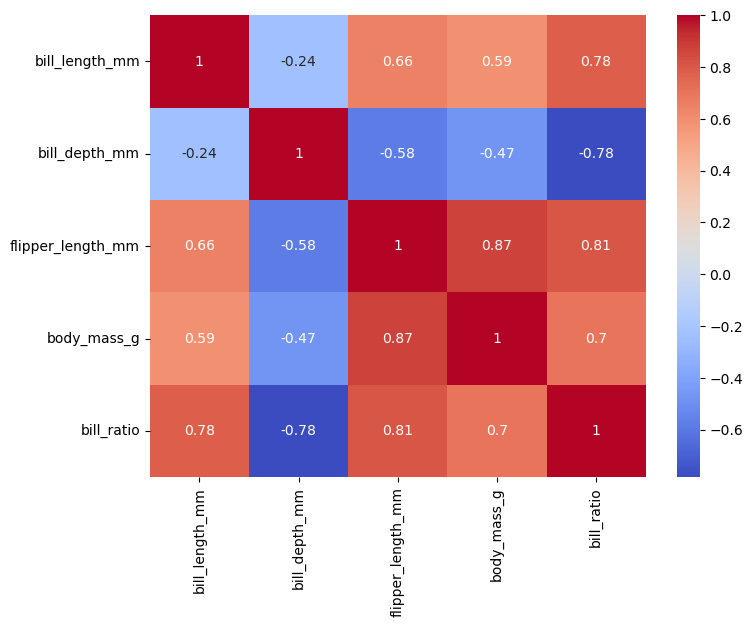

In [101]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(data=corr, cmap='coolwarm', annot=True)